In [1]:
import pandas as pd

rbps = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/mast_out/train_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python',header=None)
rbps.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']
rbps

,sequence_name,strand,id,alt_id,hit_start,hit_end,score,p_value
0,FBtr0081843_5utr,13,RNCMPT00010,CG5213,4,11,301.08,0.007690
1,FBtr0081843_5utr,12,RNCMPT00009,CG33714,12,18,502.37,0.003290
2,FBtr0081843_5utr,20,RNCMPT00015,FMR1,22,28,540.65,0.003880
3,FBtr0081843_5utr,4,RNCMPT00003,ARET,35,41,565.21,0.002440
4,FBtr0081843_5utr,2,RNCMPT00270,ARET,44,50,811.85,0.000737
...,...,...,...,...,...,...,...,...
287063,FBtr0089106_3utr,16,RNCMPT00008,CNOT4,349,355,626.00,0.002610
287064,FBtr0089106_3utr,9,RNCMPT00131,CG17838,360,366,392.22,0.006080
287065,FBtr0089106_3utr,33,RNCMPT00040,MSI,367,373,459.51,0.003580
287066,FBtr0089106_3utr,47,RNCMPT00142,QKR58E-1,375,381,912.86,0.000315


In [2]:
sg = rbps[rbps['alt_id'] == 'SF2'] #.isin(['ROX8','EIF-2ALPHA','PABP'])]
sg['tr_id'] = sg['sequence_name'].apply(lambda x: x.split('_')[0])
sg

/tmp/ipykernel_3281017/3885464872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sg['tr_id'] = sg['sequence_name'].apply(lambda x: x.split('_')[0])


,sequence_name,strand,id,alt_id,hit_start,hit_end,score,p_value,tr_id
41,FBtr0081843_3utr,57,RNCMPT00066,SF2,46,52,864.39,0.000531,FBtr0081843
258,FBtr0081981_5utr,57,RNCMPT00066,SF2,47,53,745.39,0.000970,FBtr0081981
370,FBtr0334701_3utr,57,RNCMPT00066,SF2,307,313,261.43,0.005710,FBtr0334701
376,FBtr0334701_3utr,57,RNCMPT00066,SF2,358,364,142.43,0.009250,FBtr0334701
583,FBtr0082167_5utr,57,RNCMPT00066,SF2,231,237,864.39,0.000531,FBtr0082167
...,...,...,...,...,...,...,...,...,...
286445,FBtr0302874_3utr,57,RNCMPT00066,SF2,138,144,832.66,0.000686,FBtr0302874
286576,FBtr0310541_5utr,57,RNCMPT00066,SF2,202,208,190.03,0.007200,FBtr0310541
286602,FBtr0310541_5utr,57,RNCMPT00066,SF2,443,449,1142.07,0.000086,FBtr0310541
286616,FBtr0310541_5utr,57,RNCMPT00066,SF2,571,577,229.70,0.006540,FBtr0310541


In [10]:
totalHits = pd.crosstab(sg['tr_id'], sg['alt_id'])
totalHits

alt_id,SF2
tr_id,
FBtr0070063,3
FBtr0070091,4
FBtr0070108,1
FBtr0070120,1
FBtr0070132,4
...,...
FBtr0479887,2
FBtr0479992,5
FBtr0481647,3


In [3]:
df = sg.copy() #pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/mast_out/train_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python',header=None)
#df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']
# Count unique RBPs in alt_id column
unique_rbps = df['alt_id'].nunique()
print(f"Number of unique RBPs: {unique_rbps}")

# Create new column 'trID' by splitting sequence_name on '_' and taking index 0
df['trID'] = df['sequence_name'].str.split('_').str[0]

highSHAP = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/train/positive/motif_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
highControl = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/train/positive/control_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
lowSHAP = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/train/negative/motif_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
lowControl = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/train/negative/control_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')

# --- New code: split each into 5' and 3' UTR dataframes and match length distributions ---
def _reorder_lengths_median_alternating(lengths_list):
    """
    Reorders a list of numbers to have the middle number first,
    then alternates one lower and one higher, so that the median
    number is first and the extreme values come last.
    """
    if not lengths_list:
        return []

    # Sort the list to easily find the median and subsequent elements
    sorted_lengths = sorted(lengths_list)
    n = len(sorted_lengths)
    
    new_order_lengths = []
    
    # Determine the starting middle index.
    # For odd n, (n-1)//2 is the exact middle.
    # For even n, (n-1)//2 is the lower of the two middle elements, which will be picked first.
    mid_idx = (n - 1) // 2
    
    # Add the first middle element
    new_order_lengths.append(sorted_lengths[mid_idx])
    
    # Initialize pointers for elements to the left and right of the initial middle element
    l_ptr = mid_idx - 1
    r_ptr = mid_idx + 1
    
    # Loop until all elements from sorted_lengths are added to new_order_lengths,
    # alternating between picking from the left and right sides of the initial middle.
    while l_ptr >= 0 or r_ptr < n:
        # Add element from the left side (lower than current median elements)
        if l_ptr >= 0:
            new_order_lengths.append(sorted_lengths[l_ptr])
            l_ptr -= 1
        
        # Add element from the right side (higher than current median elements)
        if r_ptr < n: 
            new_order_lengths.append(sorted_lengths[r_ptr])
            r_ptr += 1
            
    return new_order_lengths

def split_by_utr(df_regions: pd.DataFrame):
    """Return two DataFrames: 5'UTR (start <= sepStart) and 3'UTR (start > sepStart)."""
    if df_regions.empty:
        return df_regions.copy(), df_regions.copy()
    five = df_regions[df_regions['start'] <= df_regions['sepStart']].copy()
    three = df_regions[df_regions['start'] > df_regions['sepStart']].copy()
    five['length'] = five['end'] - five['start']
    three['length'] = three['end'] - three['start']
    return five, three

highSHAP_5utr, highSHAP_3utr = split_by_utr(highSHAP)
highControl_5utr, highControl_3utr = split_by_utr(highControl)
lowSHAP_5utr, lowSHAP_3utr = split_by_utr(lowSHAP)
lowControl_5utr, lowControl_3utr = split_by_utr(lowControl)

# Helper to get reordered motif lengths

def get_reordered_lengths(motif_df: pd.DataFrame):
    if motif_df.empty:
        return []
    lengths = (motif_df['end'] - motif_df['start']).astype(int)
    lengths = lengths[lengths > 0].tolist()
    return _reorder_lengths_median_alternating(lengths)

pos5_lengths = get_reordered_lengths(highSHAP_5utr)
pos3_lengths = get_reordered_lengths(highSHAP_3utr)
neg5_lengths = get_reordered_lengths(lowSHAP_5utr)
neg3_lengths = get_reordered_lengths(lowSHAP_3utr)

print("Length counts (motif): pos5", len(pos5_lengths), "pos3", len(pos3_lengths), "neg5", len(neg5_lengths), "neg3", len(neg3_lengths))

# Function to split control regions into segments matching motif length distribution (proportion-controlled, lookahead)
import random
from collections import Counter
import numpy as np
from scipy.stats import mannwhitneyu
import tqdm

def split_regions_to_lengths_proportional(control_df: pd.DataFrame, motif_lengths, random_state: int = 42):
    """Split control regions into segments whose length distribution mirrors motif_lengths.
    Strategy:
      - Maintain empirical proportion of selected lengths close to motif length frequencies.
      - For each region, iteratively allocate a length that fits remaining span.
      - Lookahead avoids creating an unusable tail (0 < tail < min_len).
      - Selection favors lengths currently underrepresented relative to motif distribution.
    """
    if control_df.empty or not motif_lengths:
        return control_df.copy()
    rnd = random.Random(random_state)
    counts = Counter(motif_lengths)  # motif length multiset
    total_motif_segments = len(motif_lengths)
    motif_freq = {L: counts[L] / total_motif_segments for L in counts}
    min_len = min(counts)
    used = Counter()
    total_segments = 0
    records = []

    for _, row in tqdm.tqdm(control_df.iterrows()):
        region_start = int(row['start'])
        region_end = int(row['end'])
        remaining = region_end - region_start
        current_start = region_start
        if remaining < min_len:
            continue  # skip too-small region
        while remaining >= min_len:
            # Candidate lengths that fit
            candidates = [L for L in counts if L <= remaining]
            if not candidates:
                break
            # Apply lookahead feasibility: avoid leaving an unusable tail
            feasible = [L for L in candidates if (remaining - L == 0) or (remaining - L >= min_len)]
            if feasible:
                candidates = feasible
            # Rank candidates by how underrepresented they would be after selection
            # imbalance = ( (used[L]+1)/(total_segments+1) ) - motif_freq[L]
            best_list = []
            best_score = None
            for L in candidates:
                new_prop = (used[L] + 1) / (total_segments + 1)
                imbalance = new_prop - motif_freq[L]
                # Prefer imbalance <= 0 (still not exceeding expected). Among those, closest to 0.
                if imbalance <= 0:
                    score = -imbalance  # smaller magnitude preferred -> larger score negative? invert
                    tag = (0, score)  # category 0 = non-overrepresented
                else:
                    score = imbalance
                    tag = (1, score)  # category 1 = overrepresented
                if best_score is None or tag < best_score:
                    best_score = tag
                    best_list = [L]
                elif tag == best_score:
                    best_list.append(L)
            # Random tie-break within best category
            chosen = rnd.choice(best_list)
            # Emit segment
            new_row = row.copy()
            new_row['orig_start'] = row['start']
            new_row['orig_end'] = row['end']
            new_row['start'] = current_start
            new_row['end'] = current_start + chosen
            new_row['length'] = chosen
            records.append(new_row)
            # Update trackers
            used[chosen] += 1
            total_segments += 1
            current_start += chosen
            remaining -= chosen
            if remaining < min_len:
                break
    if not records:
        return control_df.copy()
    return pd.DataFrame(records)

# Generate matched control sets with new proportional splitter
highControl_5utr_matched = split_regions_to_lengths_proportional(highControl_5utr, highSHAP_5utr['length'].astype(int).tolist())
highControl_3utr_matched = split_regions_to_lengths_proportional(highControl_3utr, highSHAP_3utr['length'].astype(int).tolist())
lowControl_5utr_matched = split_regions_to_lengths_proportional(lowControl_5utr, lowSHAP_5utr['length'].astype(int).tolist())
lowControl_3utr_matched = split_regions_to_lengths_proportional(lowControl_3utr, lowSHAP_3utr['length'].astype(int).tolist())

# create a more descriptive index
for d in [highSHAP_5utr, highSHAP_3utr, highControl_5utr_matched, highControl_3utr_matched, lowSHAP_5utr, lowSHAP_3utr, lowControl_5utr_matched, lowControl_3utr_matched]:
    d.index = d['trID'] + '_'+ d['start'].astype(str) + '-' + d['end'].astype(str)
pos5 = pd.DataFrame(0, index=highSHAP_5utr.index, columns=df['alt_id'].unique())
pos3 = pd.DataFrame(0, index=highSHAP_3utr.index, columns=df['alt_id'].unique())
pcontrol5 = pd.DataFrame(0, index=highControl_5utr_matched.index, columns=df['alt_id'].unique())
pcontrol3 = pd.DataFrame(0, index=highControl_3utr_matched.index, columns=df['alt_id'].unique())
neg5 = pd.DataFrame(0, index=lowSHAP_5utr.index, columns=df['alt_id'].unique())
neg3 = pd.DataFrame(0, index=lowSHAP_3utr.index, columns=df['alt_id'].unique())
ncontrol5 = pd.DataFrame(0, index=lowControl_5utr_matched.index, columns=df['alt_id'].unique())
ncontrol3 = pd.DataFrame(0, index=lowControl_3utr_matched.index, columns=df['alt_id'].unique())


for regions, tmpDF in tqdm.tqdm(zip([highSHAP_5utr, highSHAP_3utr, highControl_5utr_matched, highControl_3utr_matched, lowSHAP_5utr,lowSHAP_3utr, lowControl_5utr_matched, lowControl_3utr_matched], [pos5, pos3, pcontrol5, pcontrol3, neg5, neg3, ncontrol5, ncontrol3])):
    for r in regions.iterrows():
        if r[1]['start'] > r[1]['sepStart']:
            id = r[1]['trID']+'_3utr'
            r[1]['start'] = r[1]['start'] - r[1]['sepEnd']
            r[1]['end'] = r[1]['end'] - r[1]['sepEnd']
        else:
            id = r[1]['trID']+'_5utr'
        if id in df['sequence_name'].values:
            tmp = df[df['sequence_name'] == id]
            for t in tmp.iterrows():
                if (t[1]['hit_start'] >= r[1]['start'] and t[1]['hit_start'] <= r[1]['end']) or (t[1]['hit_end'] >= r[1]['start'] and t[1]['hit_end'] <= r[1]['end']):
                    tmpDF.loc[r[0],t[1]['alt_id']] += 1


Number of unique RBPs: 1
Length counts (motif): pos5 3835 pos3 1335 neg5 2849 neg3 5480


6974it [00:05, 1179.89it/s]
10948it [00:18, 581.08it/s]
9444it [00:14, 670.17it/s]
8633it [00:09, 923.25it/s] 
8it [00:25,  3.13s/it]


In [4]:
pos5['sum'] = pos5.sum(axis=1)
pos3['sum'] = pos3.sum(axis=1)
pcontrol5['sum'] = pcontrol5.sum(axis=1)
pcontrol3['sum'] = pcontrol3.sum(axis=1)
neg5['sum'] = neg5.sum(axis=1)
neg3['sum'] = neg3.sum(axis=1)
ncontrol5['sum'] = ncontrol5.sum(axis=1)
ncontrol3['sum'] = ncontrol3.sum(axis=1)    

pos5['tr_id'] = [i.split('_')[0] for i in pos5.index]
pos3['tr_id'] = [i.split('_')[0] for i in pos3.index]
pcontrol5['tr_id'] = [i.split('_')[0] for i in pcontrol5.index]
pcontrol3['tr_id'] = [i.split('_')[0] for i in pcontrol3.index]
neg5['tr_id'] = [i.split('_')[0] for i in neg5.index]
neg3['tr_id'] = [i.split('_')[0] for i in neg3.index]
ncontrol5['tr_id'] = [i.split('_')[0] for i in ncontrol5.index]
ncontrol3['tr_id'] = [i.split('_')[0] for i in ncontrol3.index]

pos5

,SF2,sum,tr_id
FBtr0081843_0-44,0,0,FBtr0081843
FBtr0084166_0-20,0,0,FBtr0084166
FBtr0100446_21-48,0,0,FBtr0100446
FBtr0078857_0-8,0,0,FBtr0078857
FBtr0078857_47-58,0,0,FBtr0078857
...,...,...,...
FBtr0079924_70-88,0,0,FBtr0079924
FBtr0079139_124-146,0,0,FBtr0079139
FBtr0089223_99-152,0,0,FBtr0089223
FBtr0089096_126-211,0,0,FBtr0089096


In [5]:
from Bio import SeqIO
sequences = list(SeqIO.parse("/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/decay/train.fasta", "fasta"))
ids = [r.description.split()[1] for r in sequences]
TE = [r.id for r in sequences]
sequences_dict = {record.description.split()[1]:record.id for record in sequences}
sequences_dict_len = {record.description.split()[1]:len(record.seq) for record in sequences}

In [6]:
pos5_collapsed = pos5.groupby('tr_id')['sum'].sum()
pos3_collapsed = pos3.groupby('tr_id')['sum'].sum()
neg5_collapsed = neg5.groupby('tr_id')['sum'].sum()
neg3_collapsed = neg3.groupby('tr_id')['sum'].sum()
pos5_collapsed = pos5.groupby('tr_id')['sum'].sum().reset_index()
pos3_collapsed = pos3.groupby('tr_id')['sum'].sum().reset_index()
neg5_collapsed = neg5.groupby('tr_id')['sum'].sum().reset_index()
neg3_collapsed = neg3.groupby('tr_id')['sum'].sum().reset_index()

pos5_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in pos5_collapsed['tr_id']]
pos3_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in pos3_collapsed['tr_id']]
neg5_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in neg5_collapsed['tr_id']]
neg3_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in neg3_collapsed['tr_id']]

neg5_collapsed


,tr_id,sum,TE
0,FBtr0070008,0,0.516353348995696
1,FBtr0070026,0,0.32139279563358436
2,FBtr0070045,0,0.22355933961073582
3,FBtr0070063,0,0.36066726120065035
4,FBtr0070079,0,0.6236084800307293
...,...,...,...
2023,FBtr0479872,0,0.39192931043790535
2024,FBtr0479887,0,0.41215071083407606
2025,FBtr0479901,0,0.5900618196050569
2026,FBtr0481647,0,0.3497662074927064


In [7]:
merged = pd.merge(pos5_collapsed[['tr_id','sum']], pos3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
mergedNeg = pd.merge(neg5_collapsed[['tr_id','sum']], neg3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
m = pd.merge(merged, mergedNeg, on='tr_id', suffixes=('_pos', '_neg'),how='outer')
m = m.fillna(0)
m['pos_sum'] = m['sum_5utr_pos'] + m['sum_3utr_pos']
m['neg_sum'] = m['sum_5utr_neg'] + m['sum_3utr_neg']
m['lengths'] = [sequences_dict_len.get(tr_id, None) for tr_id in m['tr_id']]
m

,tr_id,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,lengths
0,FBtr0070008,0.0,0.0,0.0,0.0,0.0,0.0,276
1,FBtr0070025,0.0,0.0,0.0,0.0,0.0,0.0,282
2,FBtr0070026,0.0,0.0,0.0,0.0,0.0,0.0,246
3,FBtr0070038,0.0,0.0,0.0,0.0,0.0,0.0,247
4,FBtr0070045,0.0,0.0,0.0,0.0,0.0,0.0,128
...,...,...,...,...,...,...,...,...
4191,FBtr0343126,0.0,0.0,0.0,0.0,0.0,0.0,661
4192,FBtr0344117,0.0,0.0,0.0,0.0,0.0,0.0,270
4193,FBtr0344826,0.0,0.0,0.0,0.0,0.0,0.0,571
4194,FBtr0344994,0.0,0.0,0.0,0.0,0.0,0.0,470


In [15]:
totalAndHighHits = pd.merge(totalHits, m, on='tr_id', how='outer')
totalAndHighHits['SF2'].fillna(0,inplace=True)
totalAndHighHits

,tr_id,SF2,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,lengths
0,FBtr0070063,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1625.0
1,FBtr0070091,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1054.0
2,FBtr0070108,1.0,0.0,1.0,0.0,0.0,1.0,0.0,565.0
3,FBtr0070120,1.0,0.0,0.0,0.0,0.0,0.0,0.0,924.0
4,FBtr0070132,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2233.0
...,...,...,...,...,...,...,...,...,...
4223,FBtr0342905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212.0
4224,FBtr0344117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,270.0
4225,FBtr0344826,0.0,0.0,0.0,0.0,0.0,0.0,0.0,571.0
4226,FBtr0344994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,470.0


In [20]:
print(len(totalAndHighHits[(totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['pos_sum'] == 0 ) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['pos_sum'] > 0) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['pos_sum'] > 0)&(totalAndHighHits['neg_sum'] == 0) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['pos_sum'] > 0) & (totalAndHighHits['SF2'] == totalAndHighHits['pos_sum'])]))

print()
print(len(totalAndHighHits[(totalAndHighHits['neg_sum'] == 0 )&(totalAndHighHits['pos_sum'] == 0 ) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['neg_sum'] > 0) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['pos_sum'] == 0)&(totalAndHighHits['neg_sum'] > 0) & (totalAndHighHits['SF2'] > 0)]))
print(len(totalAndHighHits[(totalAndHighHits['neg_sum'] > 0) & (totalAndHighHits['SF2'] == totalAndHighHits['neg_sum'])]))

1389
1069
288
278
136

1010
69
59
31


In [22]:
totalAndHighHits[(totalAndHighHits['pos_sum'] > 0) & (totalAndHighHits['SF2'] == totalAndHighHits['pos_sum'])]

,tr_id,SF2,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,lengths
2,FBtr0070108,1.0,0.0,1.0,0.0,0.0,1.0,0.0,565.0
7,FBtr0070188,1.0,0.0,1.0,0.0,0.0,1.0,0.0,367.0
15,FBtr0070269,1.0,1.0,0.0,0.0,0.0,1.0,0.0,153.0
26,FBtr0070411,1.0,0.0,1.0,0.0,0.0,1.0,0.0,404.0
28,FBtr0070425,1.0,1.0,0.0,0.0,0.0,1.0,0.0,226.0
...,...,...,...,...,...,...,...,...,...
1291,FBtr0339712,1.0,0.0,1.0,0.0,0.0,1.0,0.0,536.0
1353,FBtr0344843,1.0,0.0,1.0,0.0,0.0,1.0,0.0,168.0
1354,FBtr0344894,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1516.0
1367,FBtr0346618,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1373.0


In [52]:
# Install required package if needed: pip install goatools

import pandas as pd
from collections import defaultdict
from gprofiler import GProfiler

# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Get the transcript IDs that are above the best fit line + 1 SD
sg_affected_transcripts = totalAndHighHits[(totalAndHighHits['pos_sum'] > 0)]['tr_id'].values # & (totalAndHighHits['SF2'] == totalAndHighHits['pos_sum'])]['tr_id'].values
background_gene_ids = rbps['sequence_name'].apply(lambda x: x.split('_')[0]).unique() #totalAndHighHits[(totalAndHighHits['SF2'] > 0)]['tr_id'].values
# Convert transcript IDs (FBtr) to gene IDs (FBgn) using g:Profiler
aff_converted = gp.convert(organism='dmelanogaster', query=list(sg_affected_transcripts), target_namespace='FLYBASENAME_GENE')
bg_converted = gp.convert(organism='dmelanogaster', query=list(background_gene_ids), target_namespace='FLYBASENAME_GENE')

# Extract the converted gene IDs
gene_ids = aff_converted['converted'].dropna().unique().tolist()

# Update sg_affected_transcripts to use gene IDs
sg_affected_transcripts = gene_ids

background_gene_ids = bg_converted['converted'].dropna().unique().tolist()


print(f"Number of transcripts with high stress granule binding: {len(sg_affected_transcripts)}")

# Run GO enrichment analysis
# organism='dmelanogaster' for Drosophila
go_results = gp.profile(
    organism='dmelanogaster',
    query=list(sg_affected_transcripts),
    sources=['GO:BP'],  # Biological Process, Molecular Function, Cellular Component
    user_threshold=0.05,  # p-value threshold
    significance_threshold_method='fdr',  # Use FDR correction
    no_evidences=False,
    all_results=False,
    background=background_gene_ids  # Use all background gene IDs
)


if go_results is not None and len(go_results) > 0:
    # Sort by p-value
    go_results = go_results.sort_values('p_value')
    
    print(f"\nFound {len(go_results)} significantly enriched GO terms")
    print("\nTop 20 enriched GO terms:")
    print(go_results[['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']].head(20))
    
    # Save full results
    go_results.to_csv('sg_high_binding_GO_enrichment.csv', index=False)
    print("\nFull results saved to 'sg_high_binding_GO_enrichment.csv'")
    
    # Create summary by GO category
    print("\n=== Summary by GO Category ===")
    for source in ['GO:BP', 'GO:MF', 'GO:CC']:
        subset = go_results[go_results['source'] == source]
        if len(subset) > 0:
            print(f"\n{source}: {len(subset)} terms")
            print(subset[['name', 'p_value', 'intersection_size']].head(5))
else:
    print("\nNo significant GO terms found at p < 0.05")

Number of transcripts with high stress granule binding: 288

Found 9 significantly enriched GO terms

Top 20 enriched GO terms:
  source      native                                         name   p_value  \
0  GO:BP  GO:0000209                   protein polyubiquitination  0.027269   
1  GO:BP  GO:0001736             establishment of planar polarity  0.027269   
2  GO:BP  GO:0007164             establishment of tissue polarity  0.027269   
3  GO:BP  GO:0016055                        Wnt signaling pathway  0.027269   
4  GO:BP  GO:0032501             multicellular organismal process  0.027269   
5  GO:BP  GO:0032502                        developmental process  0.027269   
6  GO:BP  GO:0048731                           system development  0.027269   
7  GO:BP  GO:0048856             anatomical structure development  0.027269   
8  GO:BP  GO:0042067  establishment of ommatidial planar polarity  0.030225   

   intersection_size  term_size  
0                 13         51  
1            

In [53]:
GOIDs = go_results['native'].values
go_results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0000209,protein polyubiquitination,0.027269,True,"""Addition of multiple ubiquitin groups to a pr...",51,286,13,4247,0.045455,0.254902,query_1,[GO:0016567],"[CG14435, Ubc7, Ubc4, CG5823, CG7220, Cul4, ar...","[[IBA], [ISS], [ISS, IBA], [IBA], [IBA], [IDA]..."
1,GO:BP,GO:0001736,establishment of planar polarity,0.027269,True,"""Coordinated organization of groups of cells i...",58,286,13,4247,0.045455,0.224138,query_1,"[GO:0001738, GO:0007164]","[Rap1, sty, Frl, aop, ATP6AP2, Ras85D, sano, f...","[[IMP], [IMP], [IMP, IGI], [IMP, IGI], [IMP, I..."
2,GO:BP,GO:0007164,establishment of tissue polarity,0.027269,True,"""Coordinated organization of groups of cells i...",58,286,13,4247,0.045455,0.224138,query_1,[GO:0009653],"[Rap1, sty, Frl, aop, ATP6AP2, Ras85D, sano, f...","[[IMP], [IMP], [IMP, IGI], [IMP, IGI], [IMP, I..."
3,GO:BP,GO:0016055,Wnt signaling pathway,0.027269,True,"""The series of molecular signals initiated by ...",91,286,18,4247,0.062937,0.197802,query_1,[GO:0007166],"[fz4, flw, wmd, CkIIbeta, Notum, sfl, aop, ATP...","[[IBA, IEA], [IGI], [IEA], [IEA], [IDA, IMP, I..."
4,GO:BP,GO:0032501,multicellular organismal process,0.027269,True,"""Any biological process, occurring at the leve...",1281,286,117,4247,0.409091,0.091335,query_1,[GO:0008150],"[G9a, a6, Rbcn-3B, boi, dnc, Act5C, CG12236, o...","[[IMP], [IEP], [IMP], [IGI, IBA, IEA], [IMP, T..."
5,GO:BP,GO:0032502,developmental process,0.027269,True,"""A biological process whose specific outcome i...",1340,286,120,4247,0.419580,0.089552,query_1,[GO:0008150],"[G9a, a6, Rbcn-3B, boi, dnc, Act5C, CG12236, D...","[[IMP], [IEP], [IMP], [IGI, IBA, IEA], [IMP], ..."
6,GO:BP,GO:0048731,system development,0.027269,True,"""The process whose specific outcome is the pro...",792,286,79,4247,0.276224,0.099747,query_1,"[GO:0007275, GO:0048856]","[G9a, Rbcn-3B, boi, dnc, CG12236, unc-119, fs(...","[[IMP], [IMP], [IGI, IBA, IEA], [IMP], [IEA], ..."
7,GO:BP,GO:0048856,anatomical structure development,0.027269,True,"""The biological process whose specific outcome...",1279,286,116,4247,0.405594,0.090696,query_1,[GO:0032502],"[G9a, a6, Rbcn-3B, boi, dnc, Act5C, CG12236, D...","[[IMP], [IEP], [IMP], [IGI, IBA, IEA], [IMP], ..."
8,GO:BP,GO:0042067,establishment of ommatidial planar polarity,0.030225,True,"""The specification of polarized ommatidia. Omm...",37,286,10,4247,0.034965,0.270270,query_1,"[GO:0001736, GO:0001745, GO:0007163]","[Rap1, sty, Frl, aop, Ras85D, sano, fj, Jra, e...","[[IMP], [IMP], [IMP, IGI], [IMP], [IMP], [IDA]..."


In [61]:
# Install required package if needed: pip install goatools

import pandas as pd
from collections import defaultdict
from gprofiler import GProfiler

# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Get the transcript IDs that are above the best fit line + 1 SD
sg_affected_transcripts = totalAndHighHits[(totalAndHighHits['neg_sum'] > 0)]['tr_id'].values # & (totalAndHighHits['SF2'] == totalAndHighHits['pos_sum'])]['tr_id'].values
background_gene_ids = rbps['sequence_name'].apply(lambda x: x.split('_')[0]).unique() #totalAndHighHits[(totalAndHighHits['SF2'] > 0)]['tr_id'].values
# Convert transcript IDs (FBtr) to gene IDs (FBgn) using g:Profiler
aff_converted = gp.convert(organism='dmelanogaster', query=list(sg_affected_transcripts), target_namespace='FLYBASENAME_GENE')
bg_converted = gp.convert(organism='dmelanogaster', query=list(background_gene_ids), target_namespace='FLYBASENAME_GENE')

# Extract the converted gene IDs
gene_ids = aff_converted['converted'].dropna().unique().tolist()

# Update sg_affected_transcripts to use gene IDs
sg_affected_transcripts = gene_ids

background_gene_ids = bg_converted['converted'].dropna().unique().tolist()


print(f"Number of transcripts with high stress granule binding: {len(sg_affected_transcripts)}")

# Run GO enrichment analysis
# organism='dmelanogaster' for Drosophila
go_results = gp.profile(
    organism='dmelanogaster',
    query=list(sg_affected_transcripts),
    sources=['GO:BP'],  # Biological Process, Molecular Function, Cellular Component
    user_threshold=0.05,  # p-value threshold
    significance_threshold_method='fdr',  # Use FDR correction
    no_evidences=False,
    all_results=True,
    background=background_gene_ids  # Use all background gene IDs
)


if go_results is not None and len(go_results) > 0:
    # Sort by p-value
    go_results = go_results.sort_values('p_value')
    
    print(f"\nFound {len(go_results)} significantly enriched GO terms")
    print("\nTop 20 enriched GO terms:")
    print(go_results[['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']].head(20))
    
    # Save full results
    go_results.to_csv('sg_high_binding_GO_enrichment.csv', index=False)
    print("\nFull results saved to 'sg_high_binding_GO_enrichment.csv'")
    
    # Create summary by GO category
    print("\n=== Summary by GO Category ===")
    for source in ['GO:BP', 'GO:MF', 'GO:CC']:
        subset = go_results[go_results['source'] == source]
        if len(subset) > 0:
            print(f"\n{source}: {len(subset)} terms")
            print(subset[['name', 'p_value', 'intersection_size']].head(5))
else:
    print("\nNo significant GO terms found at p < 0.05")

Number of transcripts with high stress granule binding: 69

Found 1310 significantly enriched GO terms

Top 20 enriched GO terms:
   source      native                                               name  \
0   GO:BP  GO:0090306                           meiotic spindle assembly   
1   GO:BP  GO:0032530             regulation of microvillus organization   
46  GO:BP  GO:0048675                                     axon extension   
47  GO:BP  GO:1903955  positive regulation of protein targeting to mi...   
48  GO:BP  GO:0051764                          actin crosslink formation   
49  GO:BP  GO:0008340                    determination of adult lifespan   
50  GO:BP  GO:0022408          negative regulation of cell-cell adhesion   
51  GO:BP  GO:0097466      ubiquitin-dependent glycoprotein ERAD pathway   
52  GO:BP  GO:1904587                           response to glycoprotein   
53  GO:BP  GO:1904382  mannose trimming involved in glycoprotein ERAD...   
38  GO:BP  GO:0050996     positive

In [62]:
GOIDs_neg = go_results['native'].values
go_results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0090306,meiotic spindle assembly,0.394134,False,"""The aggregation, arrangement and bonding toge...",12,69,2,4247,0.028986,0.166667,query_1,"[GO:0000212, GO:0045132, GO:0051225]","[mgr, larp]","[[IMP], [IMP]]"
1,GO:BP,GO:0032530,regulation of microvillus organization,0.394134,False,"""Any process that modulates the frequency, rat...",1,69,1,4247,0.014493,1.000000,query_1,"[GO:0032528, GO:0120035]",[Cad99C],[[IMP]]
46,GO:BP,GO:0048675,axon extension,0.394134,False,"""Long distance growth of a single axon process...",33,69,3,4247,0.043478,0.090909,query_1,"[GO:0007409, GO:1990138]","[CadN, rut, hep]","[[IMP], [IMP], [IMP]]"
47,GO:BP,GO:1903955,positive regulation of protein targeting to mi...,0.394134,False,"""Any process that activates or increases the f...",1,69,1,4247,0.014493,1.000000,query_1,"[GO:0006626, GO:1903214, GO:1903749]",[larp],[[IMP]]
48,GO:BP,GO:0051764,actin crosslink formation,0.394134,False,"""The process in which two or more actin filame...",1,69,1,4247,0.014493,1.000000,query_1,[GO:0007015],[pigs],[[IBA]]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,GO:BP,GO:0019941,modification-dependent protein catabolic process,0.958577,False,"""The chemical reactions and pathways resulting...",186,69,1,4247,0.014493,0.005376,query_1,"[GO:0043632, GO:0051603]",[mr],"[[ISS, IEA]]"
1306,GO:BP,GO:0043632,modification-dependent macromolecule catabolic...,0.959342,False,"""The chemical reactions and pathways resulting...",188,69,1,4247,0.014493,0.005319,query_1,[GO:0009057],[mr],"[[ISS, IEA]]"
1307,GO:BP,GO:0006338,chromatin remodeling,0.970026,False,"""A dynamic process of chromatin reorganization...",206,69,1,4247,0.014493,0.004854,query_1,[GO:0006325],[ctp],[[IMP]]
1308,GO:BP,GO:0022613,ribonucleoprotein complex biogenesis,0.973340,False,"""A cellular process that results in the biosyn...",214,69,1,4247,0.014493,0.004673,query_1,[GO:0044085],[Nop56],[[ISS]]


In [58]:
# Install required package if needed: pip install goatools

import pandas as pd
from collections import defaultdict
from gprofiler import GProfiler

# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Get the transcript IDs that are above the best fit line + 1 SD
sg_affected_transcripts = totalAndHighHits[(totalAndHighHits['SF2'] > 0)& (totalAndHighHits['pos_sum'] == 0)]['tr_id'].values # & (totalAndHighHits['SF2'] == totalAndHighHits['pos_sum'])]['tr_id'].values
background_gene_ids = rbps['sequence_name'].apply(lambda x: x.split('_')[0]).unique() #totalAndHighHits[(totalAndHighHits['SF2'] > 0)]['tr_id'].values
# Convert transcript IDs (FBtr) to gene IDs (FBgn) using g:Profiler
aff_converted = gp.convert(organism='dmelanogaster', query=list(sg_affected_transcripts), target_namespace='FLYBASENAME_GENE')
bg_converted = gp.convert(organism='dmelanogaster', query=list(background_gene_ids), target_namespace='FLYBASENAME_GENE')

# Extract the converted gene IDs
gene_ids = aff_converted['converted'].dropna().unique().tolist()

# Update sg_affected_transcripts to use gene IDs
sg_affected_transcripts = gene_ids

background_gene_ids = bg_converted['converted'].dropna().unique().tolist()


print(f"Number of transcripts with high stress granule binding: {len(sg_affected_transcripts)}")

# Run GO enrichment analysis
# organism='dmelanogaster' for Drosophila
go_results = gp.profile(
    organism='dmelanogaster',
    query=list(sg_affected_transcripts),
    sources=['GO:BP'],  # Biological Process, Molecular Function, Cellular Component
    user_threshold=0.05,  # p-value threshold
    significance_threshold_method='fdr',  # Use FDR correction
    no_evidences=False,
    all_results=True,
    background=background_gene_ids  # Use all background gene IDs
)


if go_results is not None and len(go_results) > 0:
    # Sort by p-value
    go_results = go_results.sort_values('p_value')
    
    print(f"\nFound {len(go_results)} significantly enriched GO terms")
    print("\nTop 20 enriched GO terms:")
    print(go_results[['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']].head(20))
    
    # Save full results
    go_results.to_csv('sg_high_binding_GO_enrichment.csv', index=False)
    print("\nFull results saved to 'sg_high_binding_GO_enrichment.csv'")
    
    # Create summary by GO category
    print("\n=== Summary by GO Category ===")
    for source in ['GO:BP', 'GO:MF', 'GO:CC']:
        subset = go_results[go_results['source'] == source]
        if len(subset) > 0:
            print(f"\n{source}: {len(subset)} terms")
            print(subset[['name', 'p_value', 'intersection_size']].head(5))
else:
    print("\nNo significant GO terms found at p < 0.05")

Number of transcripts with high stress granule binding: 1069

Found 4388 significantly enriched GO terms

Top 20 enriched GO terms:
   source      native                                name       p_value  \
0   GO:BP  GO:0048856    anatomical structure development  2.455577e-19   
1   GO:BP  GO:0007275  multicellular organism development  4.450368e-19   
2   GO:BP  GO:0032502               developmental process  5.068513e-18   
3   GO:BP  GO:0007399          nervous system development  7.901861e-17   
5   GO:BP  GO:0032501    multicellular organismal process  1.456418e-16   
4   GO:BP  GO:0048731                  system development  1.456418e-16   
6   GO:BP  GO:0009653  anatomical structure morphogenesis  5.978219e-15   
7   GO:BP  GO:0030154                cell differentiation  5.295040e-14   
9   GO:BP  GO:0048699               generation of neurons  5.295040e-14   
8   GO:BP  GO:0048869      cellular developmental process  5.295040e-14   
10  GO:BP  GO:0022008                      

In [59]:
go_results[go_results['native'].isin(GOIDs)]

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0048856,anatomical structure development,2.455577e-19,True,"""The biological process whose specific outcome...",1279,1066,451,4247,0.423077,0.352619,query_1,[GO:0032502],"[elav, sdk, png, DAAM, trr, csw, fs(1)K10, wds...","[[IMP, NAS], [IMP, IEA], [IMP], [IDA, IMP, IGI..."
2,GO:BP,GO:0032502,developmental process,5.068513e-18,True,"""A biological process whose specific outcome i...",1340,1066,462,4247,0.433396,0.344776,query_1,[GO:0008150],"[elav, sdk, png, DAAM, trr, csw, fs(1)K10, wds...","[[IMP, NAS], [IMP, IEA], [IMP], [IDA, IMP, IGI..."
5,GO:BP,GO:0032501,multicellular organismal process,1.456418e-16,True,"""Any biological process, occurring at the leve...",1281,1066,440,4247,0.412758,0.343482,query_1,[GO:0008150],"[elav, sdk, png, DAAM, trr, csw, fs(1)K10, wds...","[[IMP, NAS], [IMP, IEA], [IMP], [IDA, IMP, IGI..."
4,GO:BP,GO:0048731,system development,1.456418e-16,True,"""The process whose specific outcome is the pro...",792,1066,301,4247,0.282364,0.380051,query_1,"[GO:0007275, GO:0048856]","[elav, sdk, DAAM, trr, csw, wds, egh, Seipin, ...","[[IMP, NAS], [IMP, IEA], [IDA, IMP, IGI], [IMP..."
193,GO:BP,GO:0042067,establishment of ommatidial planar polarity,3.291859e-03,True,"""The specification of polarized ommatidia. Omm...",37,1066,20,4247,0.018762,0.540541,query_1,"[GO:0001736, GO:0001745, GO:0007163]","[Rala, shg, Pcyt1, dsh, mirr, msk, nmo, S, Cad...","[[IMP], [IMP], [IMP], [IMP, IGI], [IMP], [IMP]..."
210,GO:BP,GO:0001736,establishment of planar polarity,6.110834e-03,True,"""Coordinated organization of groups of cells i...",58,1066,27,4247,0.025328,0.465517,query_1,"[GO:0001738, GO:0007164]","[Rala, shg, Rac1, Pcyt1, dsh, mirr, msk, nmo, ...","[[IMP], [IMP, IEA], [IMP], [IMP], [IMP, IGI], ..."
211,GO:BP,GO:0007164,establishment of tissue polarity,6.110834e-03,True,"""Coordinated organization of groups of cells i...",58,1066,27,4247,0.025328,0.465517,query_1,[GO:0009653],"[Rala, shg, Rac1, Pcyt1, dsh, mirr, msk, nmo, ...","[[IMP], [IMP, IEA], [IMP], [IMP], [IMP, IGI], ..."
390,GO:BP,GO:0016055,Wnt signaling pathway,6.652937e-02,False,"""The series of molecular signals initiated by ...",91,1066,34,4247,0.031895,0.373626,query_1,[GO:0007166],"[Vps26, Nek2, dsh, lic, Wnt5, nkd, nmo, sgl, K...","[[IMP, IEA], [IMP, IGI], [IDA, IMP, IGI, IBA, ..."
4070,GO:BP,GO:0000209,protein polyubiquitination,9.237819e-01,False,"""Addition of multiple ubiquitin groups to a pr...",51,1066,10,4247,0.009381,0.196078,query_1,[GO:0016567],"[Traf6, mr, Herc4, CG5087, Topors, Uba1, Ube4B...","[[IMP, ISS, IBA], [IBA], [IDA], [ISS, IBA, IEA..."


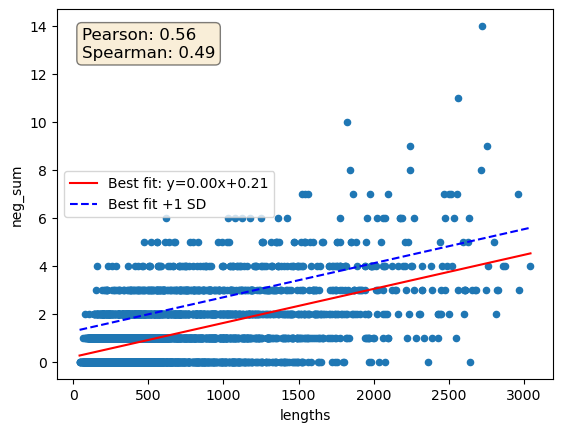

In [11]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

tmp = m[~m['lengths'].isna() & ~m['neg_sum'].isna()]

# Assuming merged_df is available from previous cells
# Plot scatter plot of neg_sum vs lengths
ax = tmp.plot.scatter(x='lengths', y='neg_sum')

# Calculate correlations
pearson_corr, _ = pearsonr(tmp['lengths'], tmp['neg_sum'])
spearman_corr, _ = spearmanr(tmp['lengths'], tmp['neg_sum'])

# Fit line of best fit
slope, intercept = np.polyfit(tmp['lengths'], tmp['neg_sum'], 1)
line_x = np.linspace(tmp['lengths'].min(), tmp['lengths'].max(), 100)
line_y = slope * line_x + intercept

# Calculate residuals and standard deviation
residuals = tmp['neg_sum'] - (slope * tmp['lengths'] + intercept)
std_dev = np.std(residuals)

# Line one standard deviation above
line_y_above = line_y + std_dev

# Add line of best fit
ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')

# Add line one std above
ax.plot(line_x, line_y_above, color='blue', linestyle='--', label=f'Best fit +1 SD')

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
plt.show()

In [17]:
tmp['above_best_fit_plus_1sd'] = tmp['neg_sum'] > (slope * tmp['lengths'] + intercept + 2*std_dev)
tmp

,tr_id,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,lengths,above_best_fit_plus_1sd
0,FBtr0070008,0.0,0.0,0.0,0.0,0.0,0.0,276,False
1,FBtr0070025,1.0,0.0,0.0,0.0,1.0,0.0,282,False
2,FBtr0070026,0.0,0.0,0.0,0.0,0.0,0.0,246,False
3,FBtr0070038,0.0,0.0,0.0,0.0,0.0,0.0,247,False
4,FBtr0070045,0.0,0.0,0.0,0.0,0.0,0.0,128,False
...,...,...,...,...,...,...,...,...,...
4205,FBtr0474236,0.0,0.0,0.0,1.0,0.0,1.0,418,False
4206,FBtr0479824,0.0,0.0,0.0,1.0,0.0,1.0,2092,False
4207,FBtr0481650,0.0,0.0,0.0,1.0,0.0,1.0,590,False
4208,FBtr0481651,0.0,0.0,0.0,2.0,0.0,2.0,766,False


In [18]:
# Install required package if needed: pip install goatools

import pandas as pd
from collections import defaultdict
from gprofiler import GProfiler

# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Get the transcript IDs that are above the best fit line + 1 SD
sg_affected_transcripts = tmp[tmp['above_best_fit_plus_1sd'] == True]['tr_id'].values
# Convert transcript IDs (FBtr) to gene IDs (FBgn) using g:Profiler
converted = gp.convert(organism='dmelanogaster', query=list(sg_affected_transcripts), target_namespace='FLYBASENAME_GENE')

# Extract the converted gene IDs
gene_ids = converted['converted'].dropna().unique().tolist()

# Update sg_affected_transcripts to use gene IDs
sg_affected_transcripts = gene_ids

converted = gp.convert(organism='dmelanogaster', query=tmp['tr_id'].tolist(), target_namespace='FLYBASENAME_GENE')
background_gene_ids = converted['converted'].dropna().unique().tolist()


print(f"Number of transcripts with high stress granule binding: {len(sg_affected_transcripts)}")

# Run GO enrichment analysis
# organism='dmelanogaster' for Drosophila
go_results = gp.profile(
    organism='dmelanogaster',
    query=list(sg_affected_transcripts),
    sources=['GO:BP'],  # Biological Process, Molecular Function, Cellular Component
    user_threshold=0.05,  # p-value threshold
    #significance_threshold_method='fdr',  # Use FDR correction
    no_evidences=False,
    all_results=True,
    background=background_gene_ids  # Use all background gene IDs
)


if go_results is not None and len(go_results) > 0:
    # Sort by p-value
    go_results = go_results.sort_values('p_value')
    
    print(f"\nFound {len(go_results)} significantly enriched GO terms")
    print("\nTop 20 enriched GO terms:")
    print(go_results[['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']].head(20))
    
    # Save full results
    go_results.to_csv('sg_high_binding_GO_enrichment.csv', index=False)
    print("\nFull results saved to 'sg_high_binding_GO_enrichment.csv'")
    
    # Create summary by GO category
    print("\n=== Summary by GO Category ===")
    for source in ['GO:BP', 'GO:MF', 'GO:CC']:
        subset = go_results[go_results['source'] == source]
        if len(subset) > 0:
            print(f"\n{source}: {len(subset)} terms")
            print(subset[['name', 'p_value', 'intersection_size']].head(5))
else:
    print("\nNo significant GO terms found at p < 0.05")

Number of transcripts with high stress granule binding: 171

Found 2157 significantly enriched GO terms

Top 20 enriched GO terms:
     source      native                                          name  \
0     GO:BP  GO:0045995           regulation of embryonic development   
1     GO:BP  GO:0016476            regulation of embryonic cell shape   
2     GO:BP  GO:0050793           regulation of developmental process   
2139  GO:BP  GO:0016198                 axon choice point recognition   
2140  GO:BP  GO:0016567                        protein ubiquitination   
2141  GO:BP  GO:0016477                                cell migration   
2142  GO:BP  GO:0016441           post-transcriptional gene silencing   
2143  GO:BP  GO:0016358                          dendrite development   
2144  GO:BP  GO:0016333        morphogenesis of follicular epithelium   
2145  GO:BP  GO:0016331         morphogenesis of embryonic epithelium   
2146  GO:BP  GO:0016322                             neuron remodel

In [19]:
go_results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:BP,GO:0045995,regulation of embryonic development,0.058702,False,"""Any process that modulates the frequency, rat...",22,170,8,4214,0.047059,0.363636,query_1,"[GO:0009790, GO:2000026]","[Rac1, Rap1, Pp2B-14D, lark, scaf, dia, Shark,...","[[IMP], [IMP], [IMP], [IMP], [IMP], [IMP], [IM..."
1,GO:BP,GO:0016476,regulation of embryonic cell shape,0.452931,False,"""Any process that modulates the surface config...",14,170,6,4214,0.035294,0.428571,query_1,"[GO:0008360, GO:0045995]","[Rac1, Rap1, scaf, dia, Shark, Rac2]","[[IMP], [IMP], [IMP], [IMP], [IMP], [IMP]]"
2,GO:BP,GO:0050793,regulation of developmental process,0.506705,False,"""Any process that modulates the frequency, rat...",375,170,33,4214,0.194118,0.088000,query_1,"[GO:0032502, GO:0050789]","[Top3beta, Rac1, Rap1, Pp2B-14D, lark, Syx7, w...","[[IMP], [IMP, IGI, IBA], [IMP, IGI], [IMP], [I..."
2139,GO:BP,GO:0016198,axon choice point recognition,1.000000,False,"""The recognition of molecules at a choice poin...",18,170,1,4214,0.005882,0.055556,query_1,"[GO:0007411, GO:0008038]",[Rac1],[[IGI]]
2140,GO:BP,GO:0016567,protein ubiquitination,1.000000,False,"""The process in which one or more ubiquitin gr...",127,170,7,4214,0.041176,0.055118,query_1,[GO:0032446],"[CG8209, Ubr3, ntc, Ube4A, Cul4, Cul1, CG5087]","[[IBA], [IDA, IMP, IBA, IEA], [IMP], [IBA, IEA..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2153,GO:BP,GO:0016236,macroautophagy,1.000000,False,"""The autophagic process that proceeds via the ...",92,170,3,4214,0.017647,0.032609,query_1,[GO:0006914],"[foxo, wdb, ntc]","[[IMP], [IMP], [IMP]]"
2154,GO:BP,GO:0016203,muscle attachment,1.000000,False,"""The developmental process in which a skeletal...",23,170,2,4214,0.011765,0.086957,query_1,"[GO:0032501, GO:0060538]","[Rac1, Rac2]","[[IGI], [IGI]]"
2155,GO:BP,GO:0016482,cytosolic transport,1.000000,False,"""The directed movement of substances or organe...",24,170,1,4214,0.005882,0.041667,query_1,[GO:0046907],[CG13784],[[IBA]]
2156,GO:BP,GO:2001252,positive regulation of chromosome organization,1.000000,False,"""Any process that activates or increases the f...",15,170,1,4214,0.005882,0.066667,query_1,"[GO:0010638, GO:0033044, GO:0051276]",[Cul1],[[IMP]]
